In [1]:
import numpy as np
import matplotlib.pyplot  as plt


/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
ref = np.load("RateAnalysis_data/reference_run_039512.npz")
print(ref)

NpzFile 'RateAnalysis_data/reference_run_039512.npz' with keys: run, channels, amplitude_bin_edges_adc, live_time_s, baseline_range...


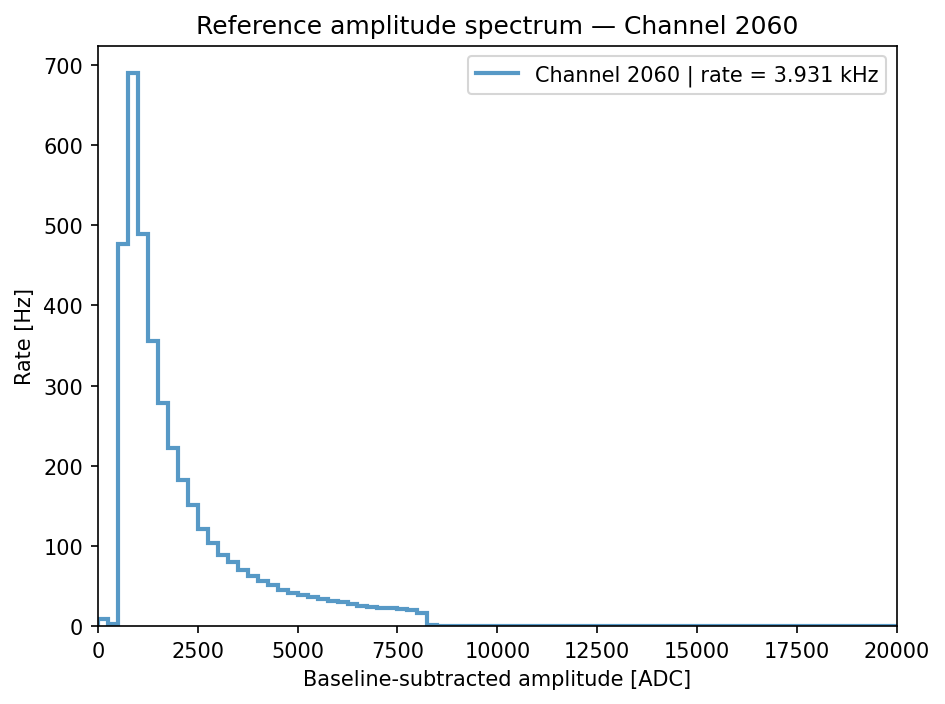

In [7]:
import numpy as np
import matplotlib.pyplot as plt

reference_file = (
    "RateAnalysis_data/reference_run_039512.npz"
)
channel_to_plot = 2060

with np.load(reference_file, allow_pickle=False) as data:
    channels = data["channels"]
    bin_edges = data["amplitude_bin_edges_adc"]
    histogram_rate_hz = data["histogram_rate_hz"]
    frequencies_khz = data["frequency_khz"]

channel_matches = np.where(channels == channel_to_plot)[0]
if channel_matches.size == 0:
    raise ValueError(f"Channel {channel_to_plot} is not in the NPZ file")

index = channel_matches[0]

plt.figure(dpi=150)
plt.stairs(
    histogram_rate_hz[index],
    bin_edges,
    linewidth=2,
    alpha=0.75,
    label=(
        f"Channel {channel_to_plot} | "
        f"rate = {frequencies_khz[index]:.3f} kHz"
    ),
)

plt.title(f"Reference amplitude spectrum — Channel {channel_to_plot}")
plt.xlabel("Baseline-subtracted amplitude [ADC]")
plt.ylabel("Rate [Hz]")
plt.xlim(bin_edges[0], bin_edges[-1])
plt.legend()
plt.tight_layout()
plt.savefig(
    f"reference_histogram_channel_{channel_to_plot}.png",
    bbox_inches="tight",
)
plt.show()
